In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("motor_insurance_eda_ready.csv")

df.head()

,INSURANCE TYPE,VEHICLE TYPE,VEHICLE USE,VEHICLE MAKE,VEHICLE MODEL,VEHICLE MAKE YEAR,SUM INSURED,POLICY PREMIUM,VEHICLE AGE,PREMIUM RATE,VEHICLE AGE BAND,LOG POLICY PREMIUM
0,Comprehensive,Car,Private,Toyota,Prius,2011,6495000.0,88691.98,14,0.013655,13+ Years,11.392936
1,Third Party,Bike,Private,Honda,CBR,2004,1050000.0,1200.00,21,0.001143,13+ Years,7.090910
2,Comprehensive,Car,Private,Nissan,Sunny,1999,2450000.0,35266.26,26,0.014394,13+ Years,10.470710
3,Third Party,Car,Private,Ford,Ranger XLT,2018,24000000.0,3500.00,7,0.000146,4-7 Years,8.160804
4,Comprehensive,Truck,Private,Tata,Dimo Batta,2013,1800000.0,35278.05,12,0.019599,8-12 Years,10.471045


In [7]:
# Modeling Target (because premium is right-skewed)

df["LOG_PREMIUM"] = np.log1p(df["POLICY PREMIUM"])

In [9]:
# Define Features

features = [
    "INSURANCE TYPE",
    "VEHICLE TYPE",
    "VEHICLE MAKE",
    "VEHICLE MODEL",
    "VEHICLE AGE",
    "SUM INSURED"
]

target = "LOG_PREMIUM"

X = df[features]
y = df[target]

In [11]:
categorical_features = [
    "INSURANCE TYPE",
    "VEHICLE TYPE",
    "VEHICLE MAKE",
    "VEHICLE MODEL"
]

numeric_features = [
    "VEHICLE AGE",
    "SUM INSURED"
]

In [13]:
# Encoding Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

In [15]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [17]:
# Baseline model — Linear Regression

lin_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lin_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['INSURANCE TYPE',
                                                   'VEHICLE TYPE',
                                                   'VEHICLE MAKE',
                                                   'VEHICLE MODEL']),
                                                 ('num', 'passthrough',
                                                  ['VEHICLE AGE',
                                                   'SUM INSURED'])])),
                ('model', LinearRegression())])

In [21]:
y_pred_log = lin_model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("Linear Regression Performance")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Linear Regression Performance
MAE: 51121.46603343546
RMSE: 118842.59027133689
R2: 0.38255334218603343


In [23]:
# Random Forest Model

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['INSURANCE TYPE',
                                                   'VEHICLE TYPE',
                                                   'VEHICLE MAKE',
                                                   'VEHICLE MODEL']),
                                                 ('num', 'passthrough',
                                                  ['VEHICLE AGE',
                                                   'SUM INSURED'])])),
                ('model',
                 RandomForestRegressor(max_depth=10, n_estimators=200,
                                       random_state=42))])

In [25]:
rf_pred_log = rf_model.predict(X_test)

rf_pred = np.expm1(rf_pred_log)

rf_mae = mean_absolute_error(y_true, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_true, rf_pred))
rf_r2 = r2_score(y_true, rf_pred)

print("Random Forest Performance")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

Random Forest Performance
MAE: 907.395946520297
RMSE: 9534.363009551374
R2: 0.9960259018176324


In [27]:
# Model Comparison

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R2": [r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,51121.466033,118842.590271,0.382553
1,Random Forest,907.395947,9534.363010,0.996026


In [29]:
# Feature importance (Random Forest)

feature_names = (
    rf_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = rf_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

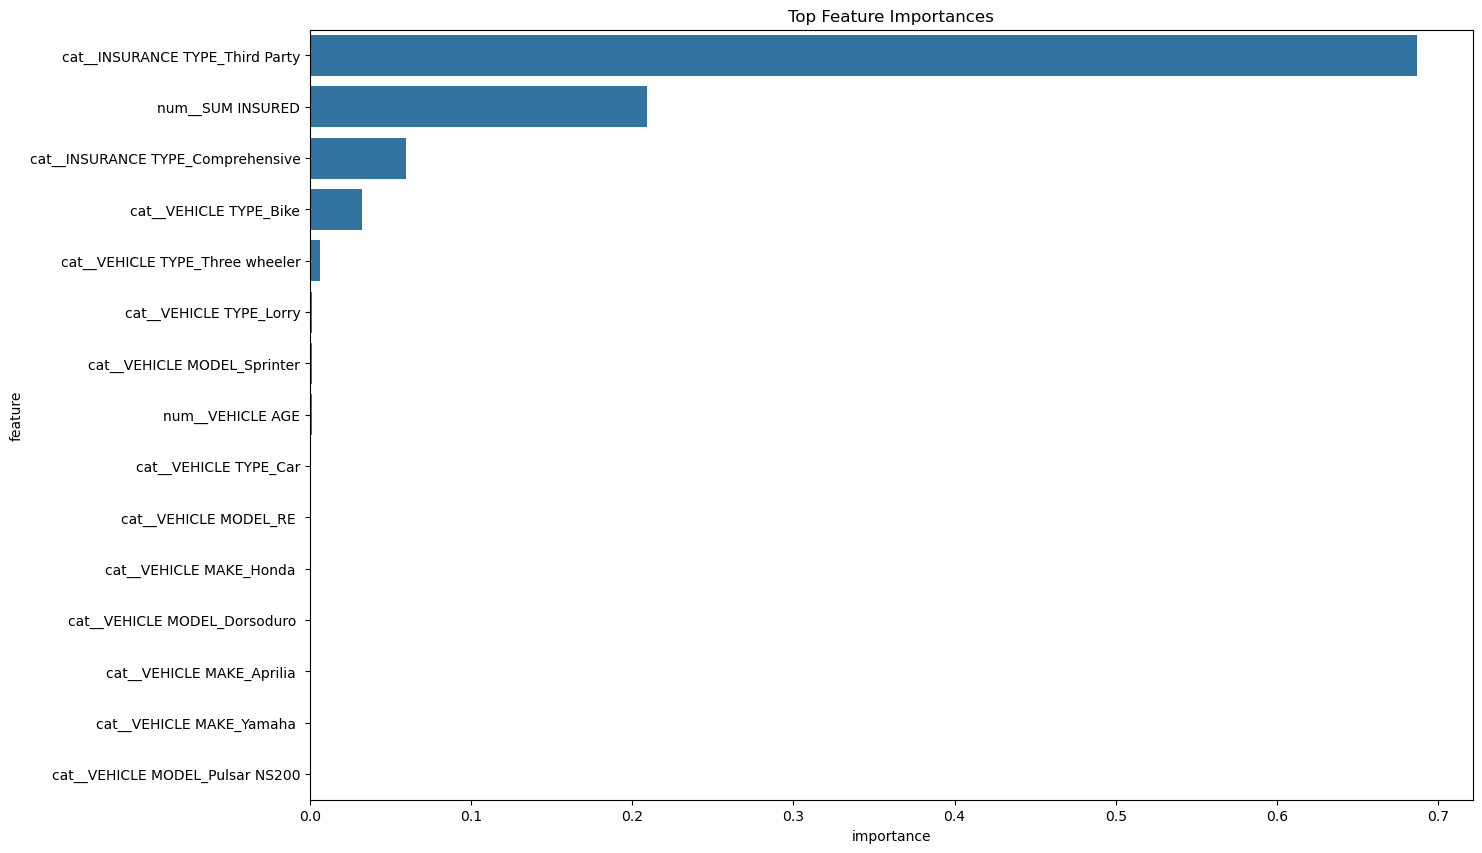

In [37]:
# Plot importance

plt.figure(figsize=(15,10))

sns.barplot(
    data=importance_df.head(15),
    x="importance",
    y="feature"
)

plt.title("Top Feature Importances")
plt.show()

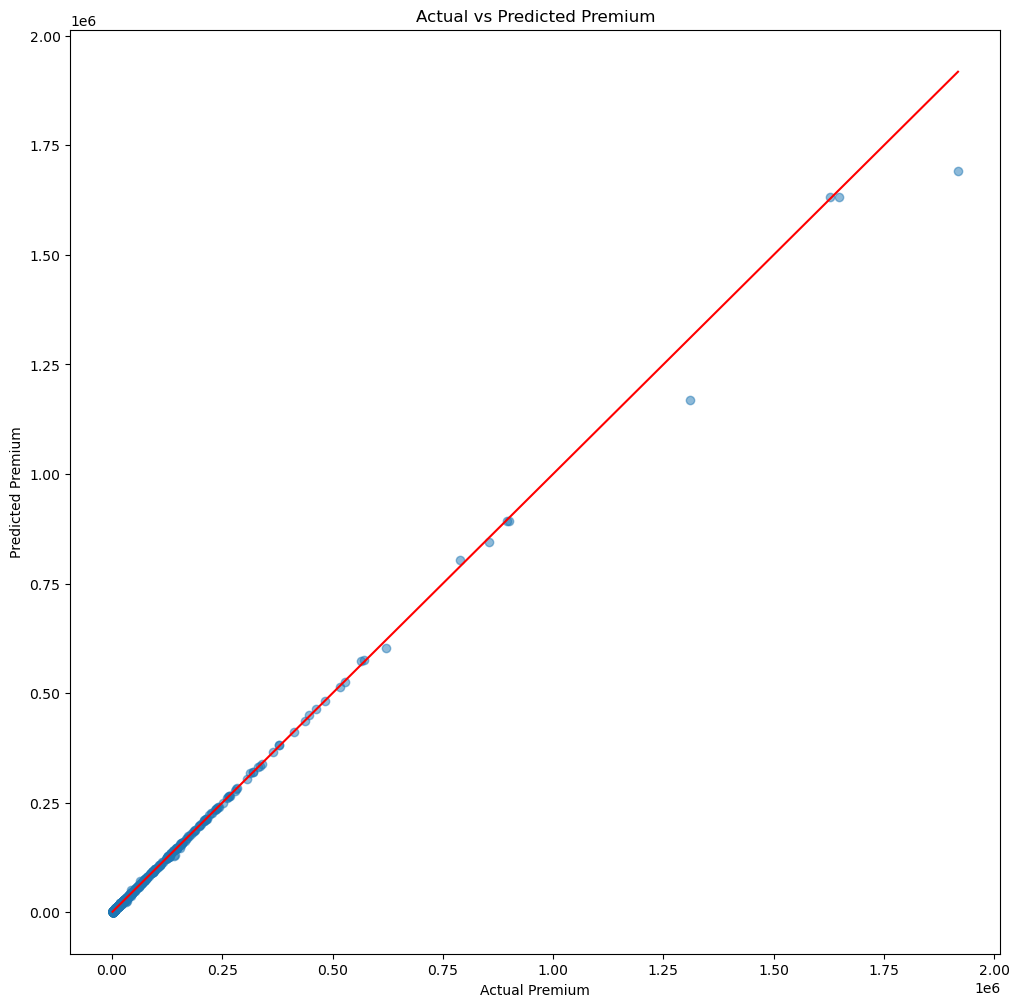

In [41]:
plt.figure(figsize=(12,12))

plt.scatter(y_true, rf_pred, alpha=0.5)

plt.xlabel("Actual Premium")
plt.ylabel("Predicted Premium")

plt.title("Actual vs Predicted Premium")

plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         color="red")

plt.show()

In [43]:
import joblib

joblib.dump(rf_model, "premium_model.pkl")

['premium_model.pkl']